# Task 15 — Production-Grade Ensemble CNN Classifier with Performance Benchmarks

This notebook implements the complete Task 15 workflow:

- CIFAR-10 dataset loading and exploration
- Train/validation/test split
- Normalization and training-only augmentation
- Three different CNN architectures
- Training with Early Stopping and Model Checkpointing
- Individual model evaluation
- Majority Voting and Soft Voting
- Confusion matrices
- Robustness testing
- Model disagreement analysis
- Latency, throughput, model size, parameter count and memory benchmarking
- Final comparison and production recommendation

**Important:** All three CNNs use the same train/validation/test split so the comparison is fair.


## 1. Project Structure

This notebook assumes it is located in:

```text
Task 15 - Production-Grade Ensemble CNN Classifier/
└── S.GayathriG40-AIML/
    ├── models/
    ├── notebooks/
    ├── results/
    ├── src/
    ├── README.md
    └── requirements.txt
```

The notebook automatically creates `models/` and `results/` if they do not exist.


In [1]:
# Cell 1 — Imports

import os
import time
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)


TensorFlow version: 2.21.0
NumPy version: 2.5.2


In [2]:
# Cell 2 — Reproducibility and Configuration

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Main training configuration from the task specification.
BATCH_SIZE = 32
MAX_EPOCHS = 30
LEARNING_RATE = 0.001

# Use a validation split of 10% from the original CIFAR-10 training set.
VALIDATION_SIZE = 5000

# Set this to True if you want a quicker development run.
# For final submission, keep it False.
FAST_MODE = False

if FAST_MODE:
    TRAIN_LIMIT = 10000
    VAL_LIMIT = 1000
    TEST_LIMIT = 1000
else:
    TRAIN_LIMIT = None
    VAL_LIMIT = None
    TEST_LIMIT = None

print("Seed:", SEED)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("FAST_MODE:", FAST_MODE)


Seed: 42
Batch size: 32
Maximum epochs: 30
Learning rate: 0.001
FAST_MODE: False


In [3]:
# Cell 3 — Create Output Directories

# Works when the notebook is inside the Task 15 project folder.
PROJECT_ROOT = Path.cwd()

MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Models directory:", MODELS_DIR)
print("Results directory:", RESULTS_DIR)


Project root: c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook
Models directory: c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\models
Results directory: c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\results


## 2. Load CIFAR-10 Dataset

CIFAR-10 contains 10 image classes:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.


In [4]:
# Cell 4 — Load CIFAR-10

from tensorflow.keras.datasets import cifar10

(X_full_train, y_full_train), (X_test, y_test) = cifar10.load_data()

y_full_train = y_full_train.reshape(-1)
y_test = y_test.reshape(-1)

print("Original training images:", X_full_train.shape)
print("Original training labels:", y_full_train.shape)
print("Original test images:", X_test.shape)
print("Original test labels:", y_test.shape)


Original training images: (50000, 32, 32, 3)
Original training labels: (50000,)
Original test images: (10000, 32, 32, 3)
Original test labels: (10000,)


In [5]:
# Cell 5 — Class Names

CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes:", NUM_CLASSES)
for i, name in enumerate(CLASS_NAMES):
    print(i, "->", name)


Number of classes: 10
0 -> airplane
1 -> automobile
2 -> bird
3 -> cat
4 -> deer
5 -> dog
6 -> frog
7 -> horse
8 -> ship
9 -> truck


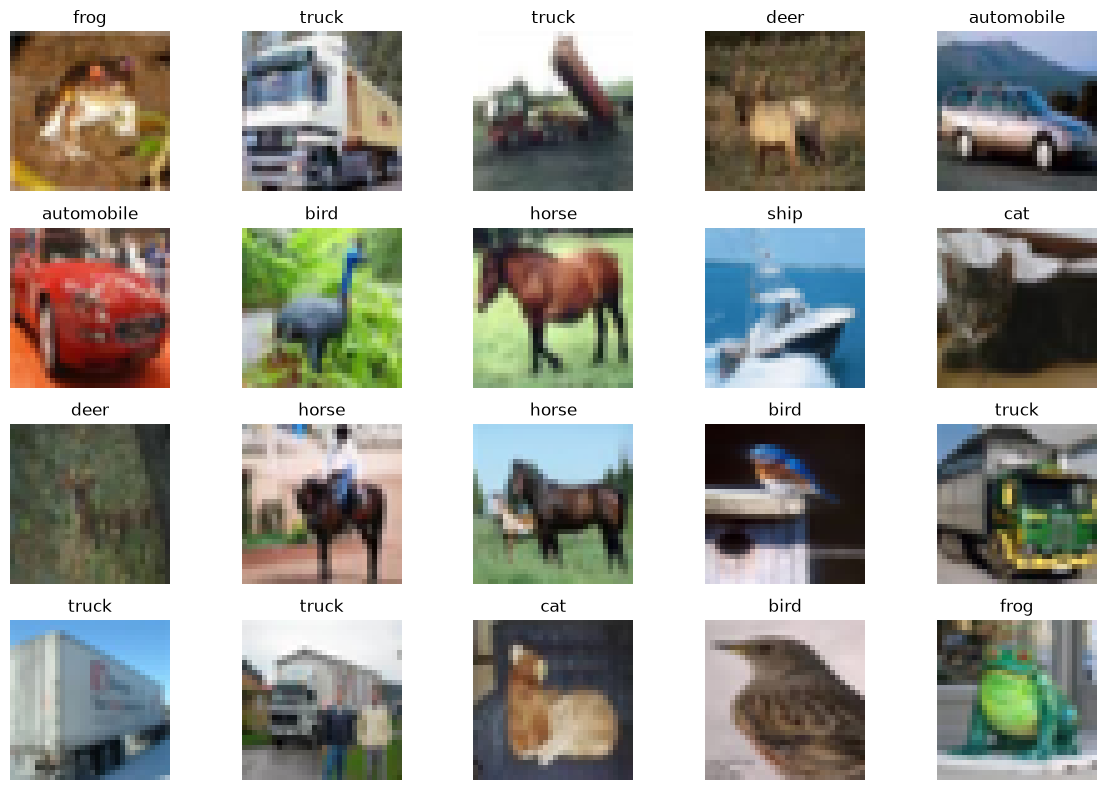

In [6]:
# Cell 6 — Visualize Sample Images

plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_full_train[i])
    plt.title(CLASS_NAMES[y_full_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
# Cell 7 — Class Distribution

class_counts = pd.Series(y_full_train).value_counts().sort_index()

distribution_df = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [CLASS_NAMES[i] for i in class_counts.index],
    "count": class_counts.values
})

display(distribution_df)


,class_id,class_name,count
0,0,airplane,5000
1,1,automobile,5000
2,2,bird,5000
3,3,cat,5000
4,4,deer,5000
5,5,dog,5000
6,6,frog,5000
7,7,horse,5000
8,8,ship,5000
9,9,truck,5000


## 3. Train / Validation / Test Split

The same split is reused for all three CNN models.

The original CIFAR-10 training set has 50,000 images. We reserve 5,000 for validation and keep the official 10,000-image test set untouched.


In [8]:
# Cell 8 — Create Train / Validation Split

# Shuffle the original training data once using a fixed seed.
rng = np.random.default_rng(SEED)
indices = rng.permutation(len(X_full_train))

X_shuffled = X_full_train[indices]
y_shuffled = y_full_train[indices]

X_val = X_shuffled[:VALIDATION_SIZE]
y_val = y_shuffled[:VALIDATION_SIZE]

X_train = X_shuffled[VALIDATION_SIZE:]
y_train = y_shuffled[VALIDATION_SIZE:]

if TRAIN_LIMIT is not None:
    X_train = X_train[:TRAIN_LIMIT]
    y_train = y_train[:TRAIN_LIMIT]

if VAL_LIMIT is not None:
    X_val = X_val[:VAL_LIMIT]
    y_val = y_val[:VAL_LIMIT]

if TEST_LIMIT is not None:
    X_test = X_test[:TEST_LIMIT]
    y_test = y_test[:TEST_LIMIT]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (45000, 32, 32, 3) (45000,)
Validation: (5000, 32, 32, 3) (5000,)
Test: (10000, 32, 32, 3) (10000,)


In [9]:
# Cell 9 — Normalize Images

# Convert uint8 [0, 255] to float32 [0, 1].
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Train range:", X_train.min(), "to", X_train.max())
print("Validation range:", X_val.min(), "to", X_val.max())
print("Test range:", X_test.min(), "to", X_test.max())


Train range: 0.0 to 1.0
Validation range: 0.0 to 1.0
Test range: 0.0 to 1.0


## 4. Data Augmentation

Augmentation is applied only during training.

The validation and test images remain unmodified for standard evaluation.


In [10]:
# Cell 10 — Training Data Augmentation

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

print(data_augmentation)


<Sequential name=data_augmentation, built=False>


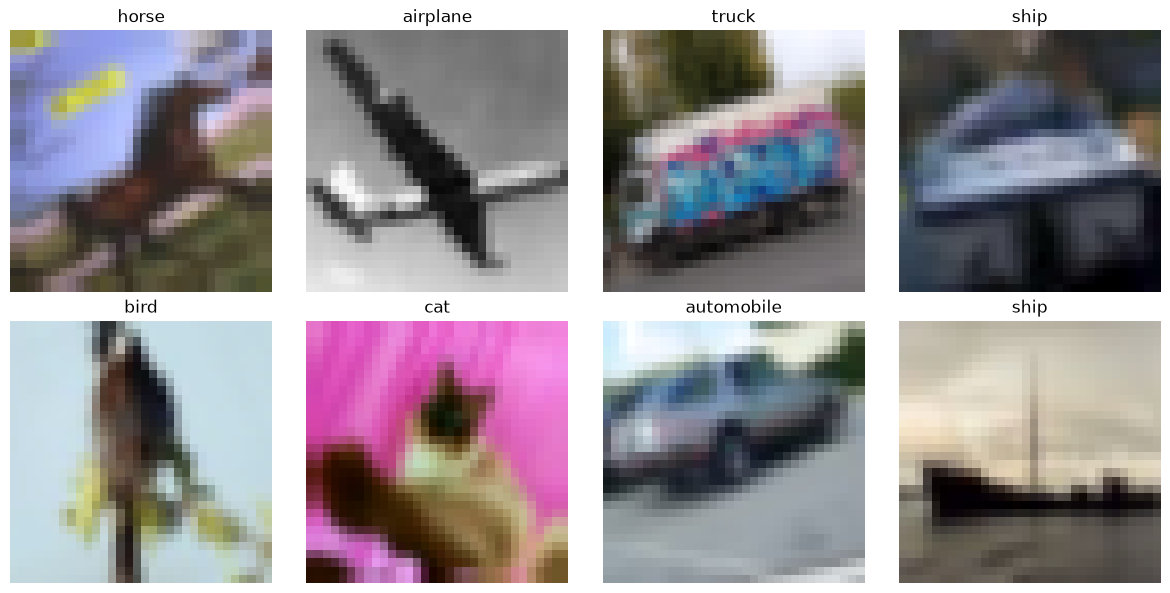

In [11]:
# Cell 11 — Visualize Augmented Images

sample_batch = X_train[:8]

augmented_batch = data_augmentation(sample_batch, training=True)

plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.clip(augmented_batch[i].numpy(), 0, 1))
    plt.title(CLASS_NAMES[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


## 5. Build CNN 1 — Baseline CNN

The first model is intentionally simple and acts as the baseline.


In [12]:
# Cell 12 — Baseline CNN

def build_baseline_cnn():
    model = keras.Sequential(
        [
            layers.Input(shape=(32, 32, 3)),
            data_augmentation,

            layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),

            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.Dense(NUM_CLASSES, activation="softmax")
        ],
        name="cnn_baseline"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn1 = build_baseline_cnn()
cnn1.summary()


Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Build CNN 2 — Regularized CNN

This model adds Batch Normalization and Dropout to improve training stability and reduce overfitting.


In [13]:
# Cell 13 — Regularized CNN

def build_regularized_cnn():
    model = keras.Sequential(
        [
            layers.Input(shape=(32, 32, 3)),
            data_augmentation,

            layers.Conv2D(32, (3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Conv2D(64, (3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.30),

            layers.Conv2D(128, (3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.35),

            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.40),
            layers.Dense(NUM_CLASSES, activation="softmax")
        ],
        name="cnn_regularized"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn2 = build_regularized_cnn()
cnn2.summary()


Model: "cnn_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 7. Build CNN 3 — Deeper CNN

The third model is deeper and uses Global Average Pooling.


In [14]:
# Cell 14 — Deep CNN

def build_deep_cnn():
    model = keras.Sequential(
        [
            layers.Input(shape=(32, 32, 3)),
            data_augmentation,

            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),

            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.35),
            layers.Dense(NUM_CLASSES, activation="softmax")
        ],
        name="cnn_deep"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn3 = build_deep_cnn()
cnn3.summary()


Model: "cnn_deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,706 (1.17 MB)

 Trainable params: 305,258 (1.16 MB)

 Non-trainable params: 448 (1.75 KB)

## 8. Training Utilities

We use:

- Early Stopping
- Model Checkpointing
- Validation monitoring

The best validation model is restored after training.


In [15]:
# Cell 15 — Training Function

def train_model(model, model_name):
    model_path = MODELS_DIR / f"{model_name}.keras"

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    start = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    elapsed = time.perf_counter() - start

    # Reload the best checkpoint if it exists.
    if model_path.exists():
        best_model = keras.models.load_model(model_path)
    else:
        best_model = model

    print(f"Training time for {model_name}: {elapsed:.2f} seconds")
    print(f"Best model saved at: {model_path}")

    return best_model, history, elapsed


In [16]:
# Cell 16 — Train CNN 1

cnn1, history1, train_time1 = train_model(cnn1, "cnn_baseline")


Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4560 - loss: 1.5168
Epoch 1: val_accuracy improved from None to 0.53180, saving model to c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\models\cnn_baseline.keras

Epoch 1: finished saving model to c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\models\cnn_baseline.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.4560 - loss: 1.5168 - val_accuracy: 0.5318 - val_loss: 1.2932 - learning_rate: 0.0010
Epoch 2/30
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5629 - loss: 1.2359
Epoch 2: val_accuracy improved from 0.53180 to 0.57600, saving model to c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensembl

In [17]:
# Cell 17 — Train CNN 2

cnn2, history2, train_time2 = train_model(cnn2, "cnn_regularized")


Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.2692 - loss: 1.9459
Epoch 1: val_accuracy improved from None to 0.39480, saving model to c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\models\cnn_regularized.keras

Epoch 1: finished saving model to c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\models\cnn_regularized.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 201s 137ms/step - accuracy: 0.2692 - loss: 1.9459 - val_accuracy: 0.3948 - val_loss: 1.6530 - learning_rate: 0.0010
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.3520 - loss: 1.7261
Epoch 2: val_accuracy improved from 0.39480 to 0.44760, saving model to c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Gra

In [18]:
# Cell 18 — Train CNN 3

cnn3, history3, train_time3 = train_model(cnn3, "cnn_deep")


Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4324 - loss: 1.5634
Epoch 1: val_accuracy improved from None to 0.44260, saving model to c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\models\cnn_deep.keras

Epoch 1: finished saving model to c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\models\cnn_deep.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 223s 154ms/step - accuracy: 0.4324 - loss: 1.5634 - val_accuracy: 0.4426 - val_loss: 1.6857 - learning_rate: 0.0010
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5701 - loss: 1.2096
Epoch 2: val_accuracy improved from 0.44260 to 0.51540, saving model to c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CN

## 9. Training History Plots


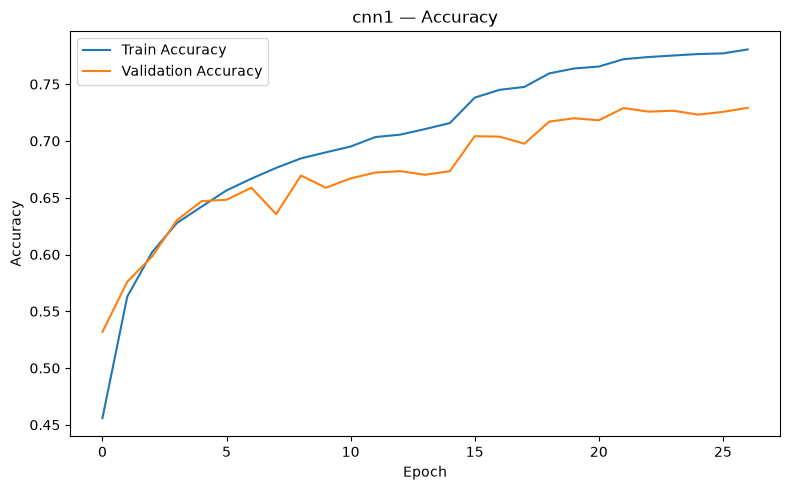

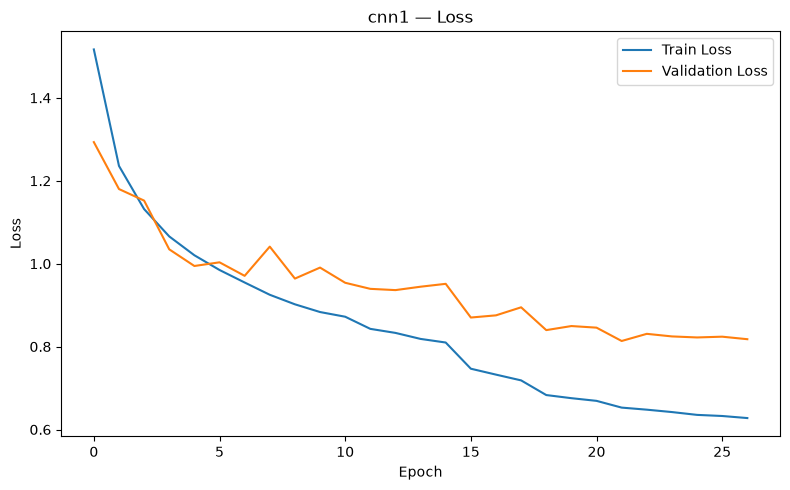

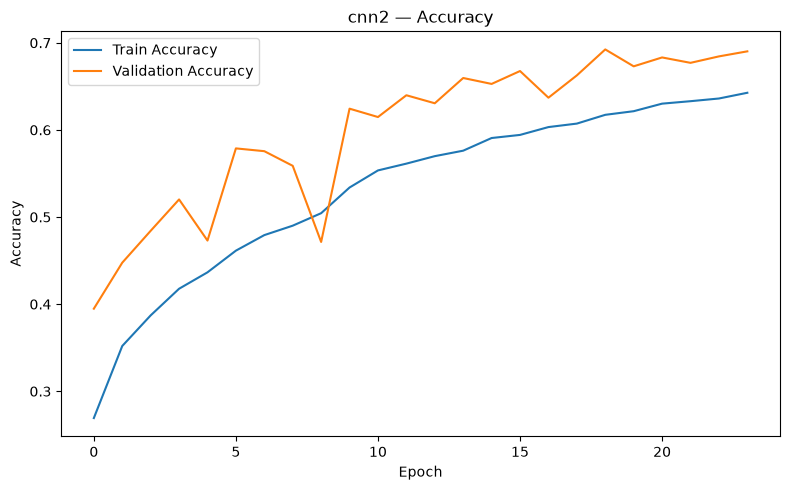

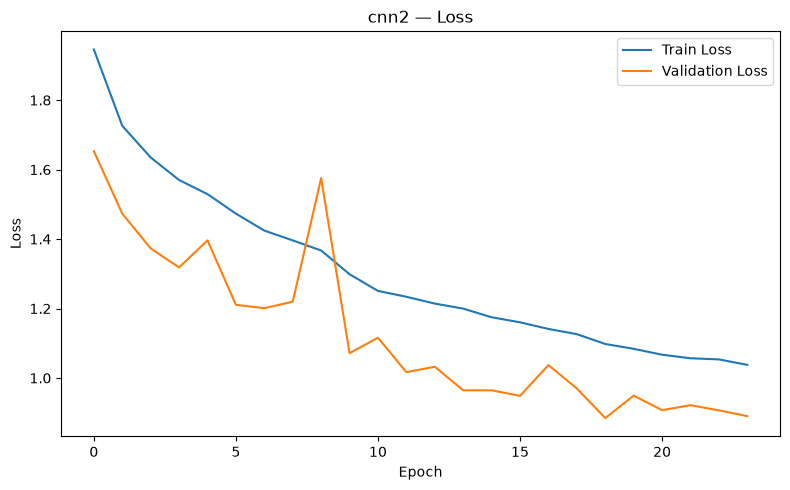

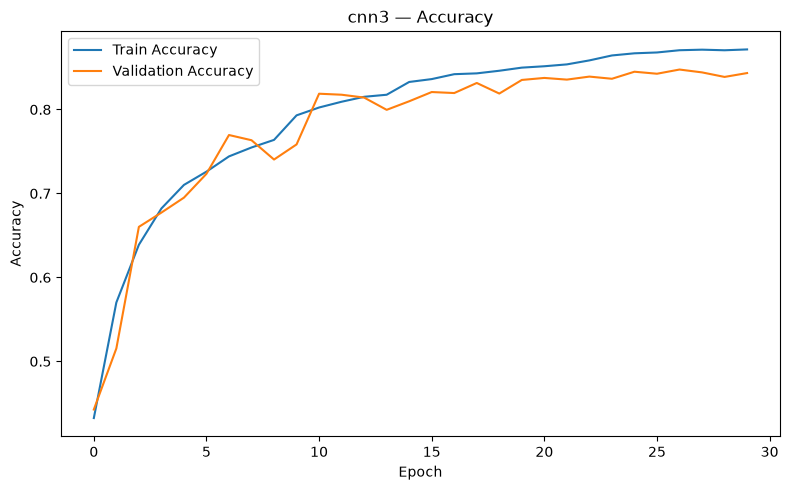

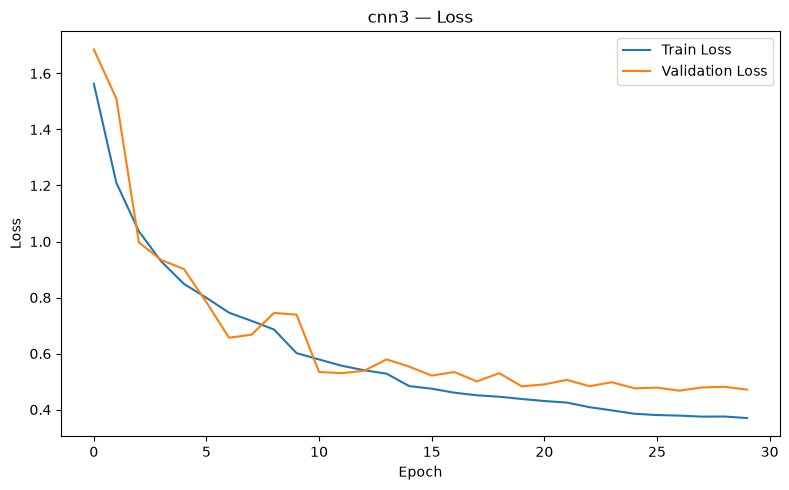

In [19]:
# Cell 19 — Plot and Save Training History

def plot_training_history(history, model_name):
    history_df = pd.DataFrame(history.history)

    history_csv = RESULTS_DIR / f"training_history_{model_name}.csv"
    history_df.to_csv(history_csv, index=False)

    fig = plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} — Accuracy")
    plt.legend()
    plt.tight_layout()

    accuracy_path = RESULTS_DIR / f"training_accuracy_{model_name}.png"
    plt.savefig(accuracy_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig = plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} — Loss")
    plt.legend()
    plt.tight_layout()

    loss_path = RESULTS_DIR / f"training_loss_{model_name}.png"
    plt.savefig(loss_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return history_df

history_df1 = plot_training_history(history1, "cnn1")
history_df2 = plot_training_history(history2, "cnn2")
history_df3 = plot_training_history(history3, "cnn3")


## 10. Individual Model Evaluation


In [20]:
# Cell 20 — Evaluation Utilities

def get_predictions(model, X):
    probabilities = model.predict(
        X,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    predictions = np.argmax(probabilities, axis=1)
    return probabilities, predictions


def evaluate_model(model, X, y, model_name):
    probabilities, predictions = get_predictions(model, X)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y, predictions),
        "precision_weighted": precision_score(
            y, predictions, average="weighted", zero_division=0
        ),
        "recall_weighted": recall_score(
            y, predictions, average="weighted", zero_division=0
        ),
        "f1_weighted": f1_score(
            y, predictions, average="weighted", zero_division=0
        ),
        "loss": model.evaluate(
            X, y, batch_size=BATCH_SIZE, verbose=0
        )[0]
    }

    return metrics, probabilities, predictions


In [21]:
# Cell 21 — Evaluate CNN 1, CNN 2 and CNN 3

metrics1, probs1, preds1 = evaluate_model(
    cnn1, X_test, y_test, "CNN 1 - Baseline"
)

metrics2, probs2, preds2 = evaluate_model(
    cnn2, X_test, y_test, "CNN 2 - Regularized"
)

metrics3, probs3, preds3 = evaluate_model(
    cnn3, X_test, y_test, "CNN 3 - Deep"
)

individual_metrics_df = pd.DataFrame([metrics1, metrics2, metrics3])

display(individual_metrics_df)


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,loss
0,CNN 1 - Baseline,0.7349,0.733782,0.7349,0.729388,0.814649
1,CNN 2 - Regularized,0.6924,0.704411,0.6924,0.683729,0.883981
2,CNN 3 - Deep,0.8454,0.844552,0.8454,0.843532,0.490724


In [22]:
# Cell 22 — Classification Reports

print("CNN 1 — Baseline")
print(
    classification_report(
        y_test,
        preds1,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

print("\nCNN 2 — Regularized")
print(
    classification_report(
        y_test,
        preds2,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

print("\nCNN 3 — Deep")
print(
    classification_report(
        y_test,
        preds3,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)


CNN 1 — Baseline
              precision    recall  f1-score   support

    airplane       0.71      0.81      0.76      1000
  automobile       0.79      0.88      0.83      1000
        bird       0.74      0.57      0.64      1000
         cat       0.64      0.46      0.53      1000
        deer       0.74      0.68      0.71      1000
         dog       0.68      0.64      0.66      1000
        frog       0.70      0.86      0.77      1000
       horse       0.72      0.83      0.77      1000
        ship       0.87      0.80      0.84      1000
       truck       0.75      0.82      0.79      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000


CNN 2 — Regularized
              precision    recall  f1-score   support

    airplane       0.76      0.73      0.75      1000
  automobile       0.85      0.87      0.86      1000
        bird       0.69      0.46      0

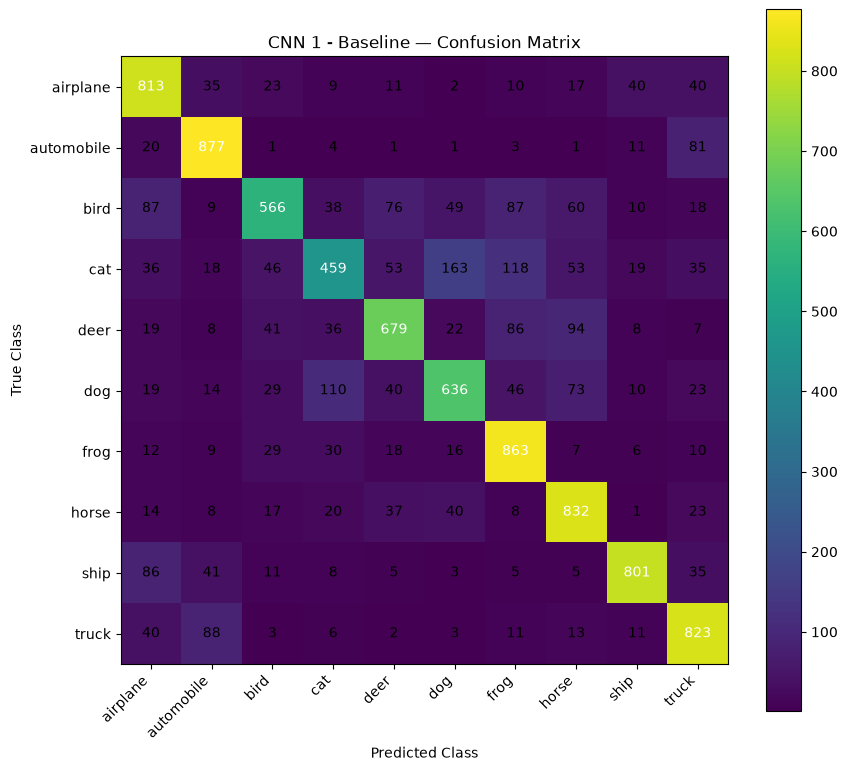

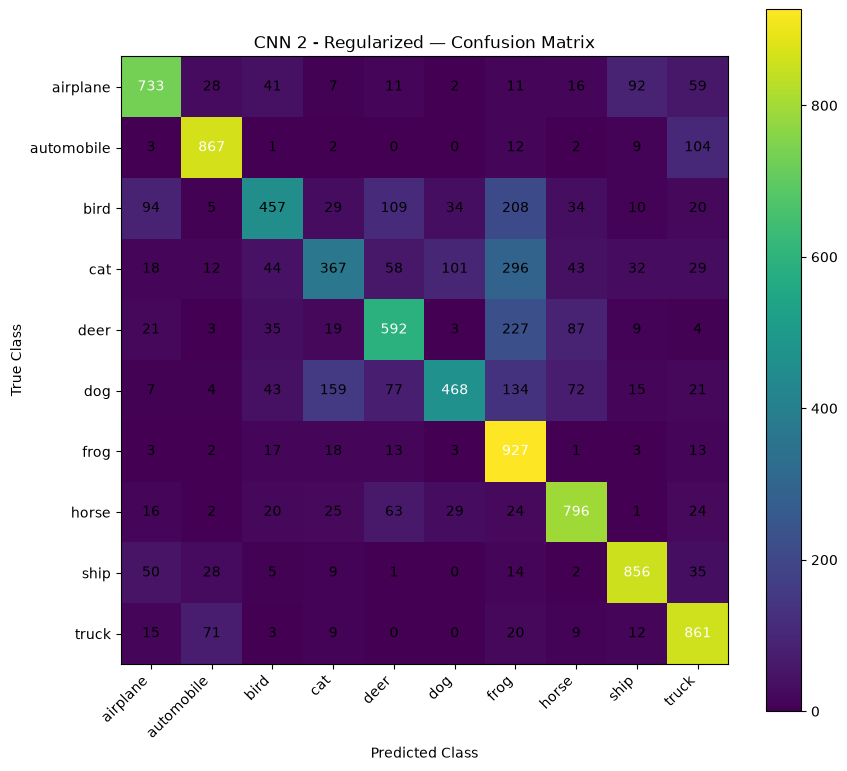

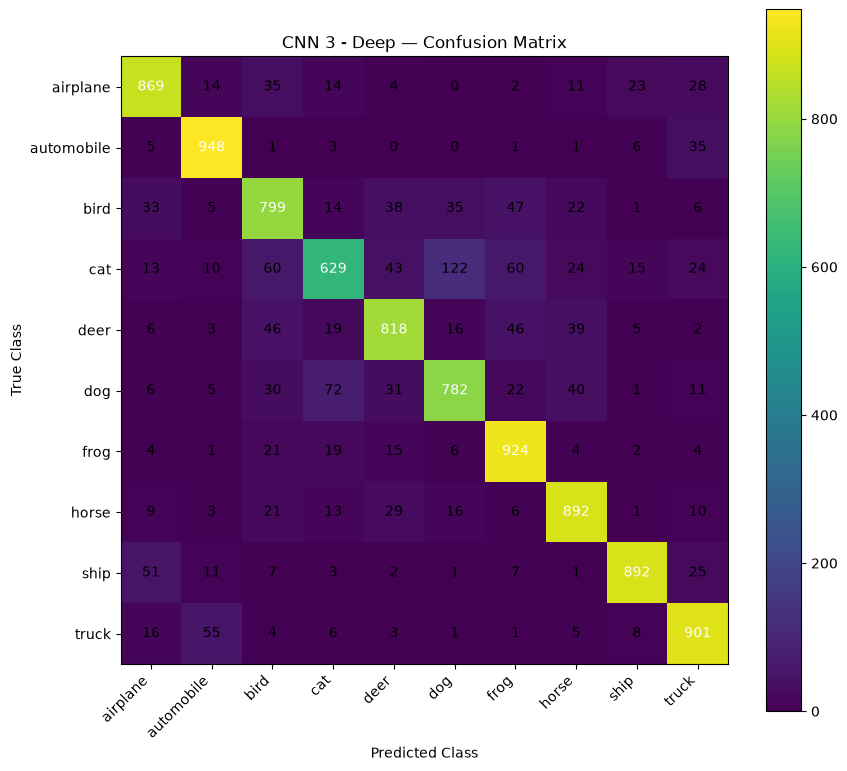

In [23]:
# Cell 23 — Confusion Matrix Utility

def save_confusion_matrix(y_true, y_pred, model_name, filename):
    cm = confusion_matrix(y_true, y_pred)

    fig = plt.figure(figsize=(9, 8))
    plt.imshow(cm)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(range(NUM_CLASSES), CLASS_NAMES)

    threshold = cm.max() / 2.0

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black"
            )

    plt.colorbar()
    plt.tight_layout()

    path = RESULTS_DIR / filename
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return cm


cm1 = save_confusion_matrix(
    y_test, preds1, "CNN 1 - Baseline", "cnn1_confusion_matrix.png"
)

cm2 = save_confusion_matrix(
    y_test, preds2, "CNN 2 - Regularized", "cnn2_confusion_matrix.png"
)

cm3 = save_confusion_matrix(
    y_test, preds3, "CNN 3 - Deep", "cnn3_confusion_matrix.png"
)


## 11. Ensemble Learning

Two required ensemble strategies are implemented:

1. **Majority Voting / Hard Voting**
2. **Soft Voting**

Soft Voting averages the class probabilities produced by the three CNNs.


In [24]:
# Cell 24 — Majority Voting

def majority_voting(prediction_arrays):
    stacked = np.stack(prediction_arrays, axis=1)

    final_predictions = []

    for row in stacked:
        counts = np.bincount(row, minlength=NUM_CLASSES)
        final_predictions.append(np.argmax(counts))

    return np.array(final_predictions)


majority_preds = majority_voting([preds1, preds2, preds3])

majority_accuracy = accuracy_score(y_test, majority_preds)

print("Majority Voting Accuracy:", majority_accuracy)


Majority Voting Accuracy: 0.7977


In [25]:
# Cell 25 — Soft Voting

def soft_voting(probability_arrays):
    average_probabilities = np.mean(
        np.stack(probability_arrays, axis=0),
        axis=0
    )

    final_predictions = np.argmax(
        average_probabilities,
        axis=1
    )

    return average_probabilities, final_predictions


soft_probs, soft_preds = soft_voting(
    [probs1, probs2, probs3]
)

soft_accuracy = accuracy_score(y_test, soft_preds)

print("Soft Voting Accuracy:", soft_accuracy)


Soft Voting Accuracy: 0.8215


In [26]:
# Cell 26 — Optional Weighted Soft Voting

# Weights are derived from validation accuracy, not the final test labels.
# This avoids choosing weights using the final test dataset.

_, val_preds1 = get_predictions(cnn1, X_val)
_, val_preds2 = get_predictions(cnn2, X_val)
_, val_preds3 = get_predictions(cnn3, X_val)

val_accs = np.array([
    accuracy_score(y_val, val_preds1),
    accuracy_score(y_val, val_preds2),
    accuracy_score(y_val, val_preds3)
])

weights = val_accs / val_accs.sum()

weighted_probs = (
    weights[0] * probs1 +
    weights[1] * probs2 +
    weights[2] * probs3
)

weighted_preds = np.argmax(weighted_probs, axis=1)

weighted_accuracy = accuracy_score(y_test, weighted_preds)

print("Validation accuracies:", val_accs)
print("Normalized weights:", weights)
print("Weighted Soft Voting test accuracy:", weighted_accuracy)


Validation accuracies: [0.7292 0.6924 0.8476]
Normalized weights: [0.32134673 0.30512956 0.37352371]
Weighted Soft Voting test accuracy: 0.8277


In [27]:
# Cell 27 — Ensemble Metrics

def calculate_prediction_metrics(y_true, predictions, model_name):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, predictions),
        "precision_weighted": precision_score(
            y_true, predictions, average="weighted", zero_division=0
        ),
        "recall_weighted": recall_score(
            y_true, predictions, average="weighted", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, predictions, average="weighted", zero_division=0
        )
    }


majority_metrics = calculate_prediction_metrics(
    y_test, majority_preds, "Majority Voting"
)

soft_metrics = calculate_prediction_metrics(
    y_test, soft_preds, "Soft Voting"
)

weighted_metrics = calculate_prediction_metrics(
    y_test, weighted_preds, "Weighted Soft Voting"
)

ensemble_metrics_df = pd.DataFrame([
    majority_metrics,
    soft_metrics,
    weighted_metrics
])

display(ensemble_metrics_df)


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Majority Voting,0.7977,0.798633,0.7977,0.794140
1,Soft Voting,0.8215,0.823389,0.8215,0.818211
2,Weighted Soft Voting,0.8277,0.828894,0.8277,0.824542


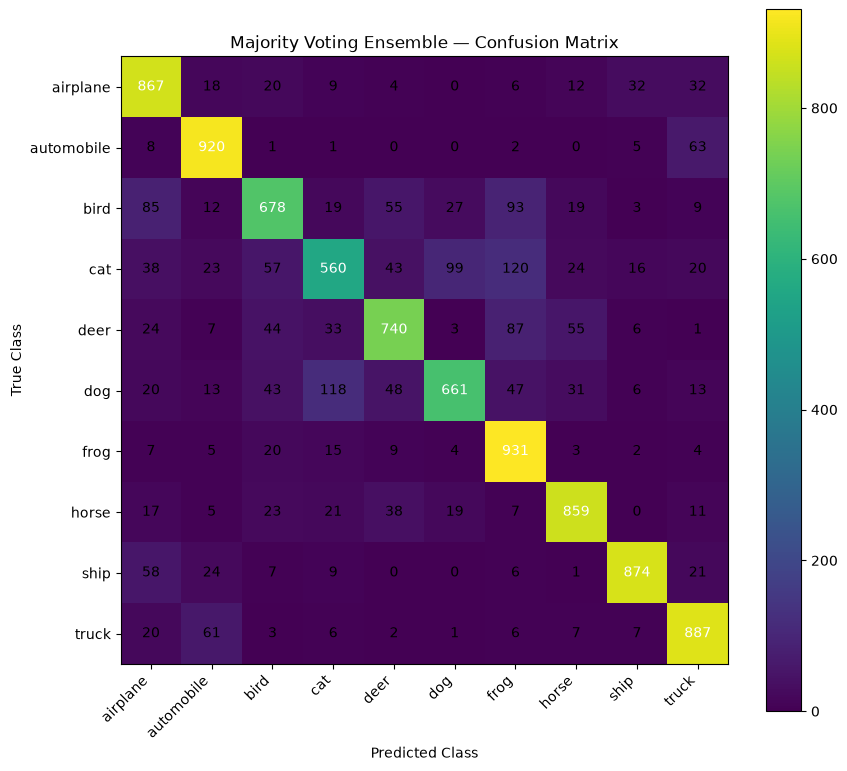

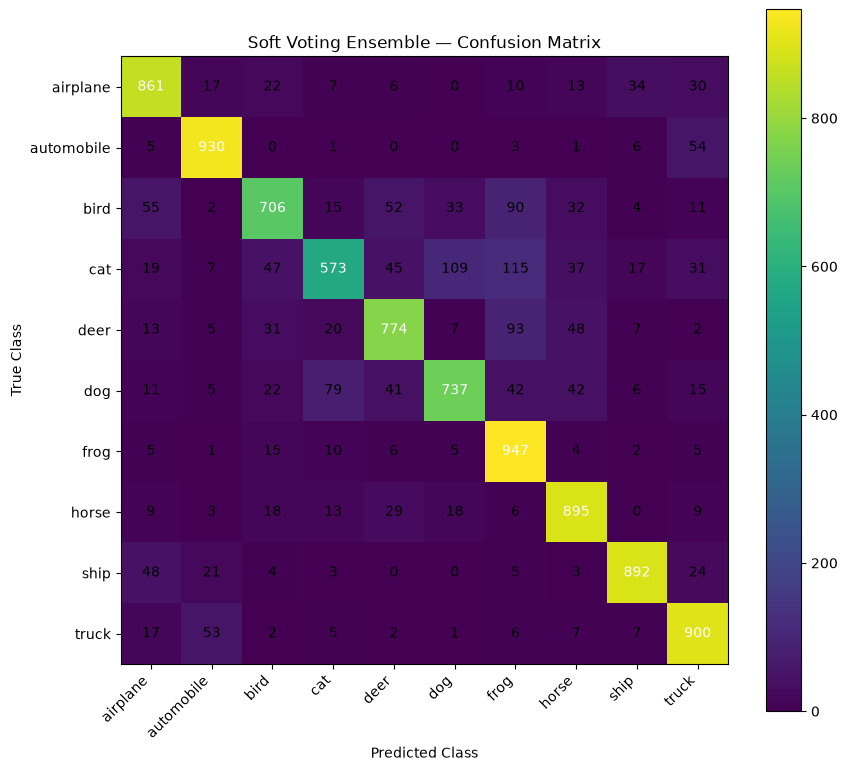

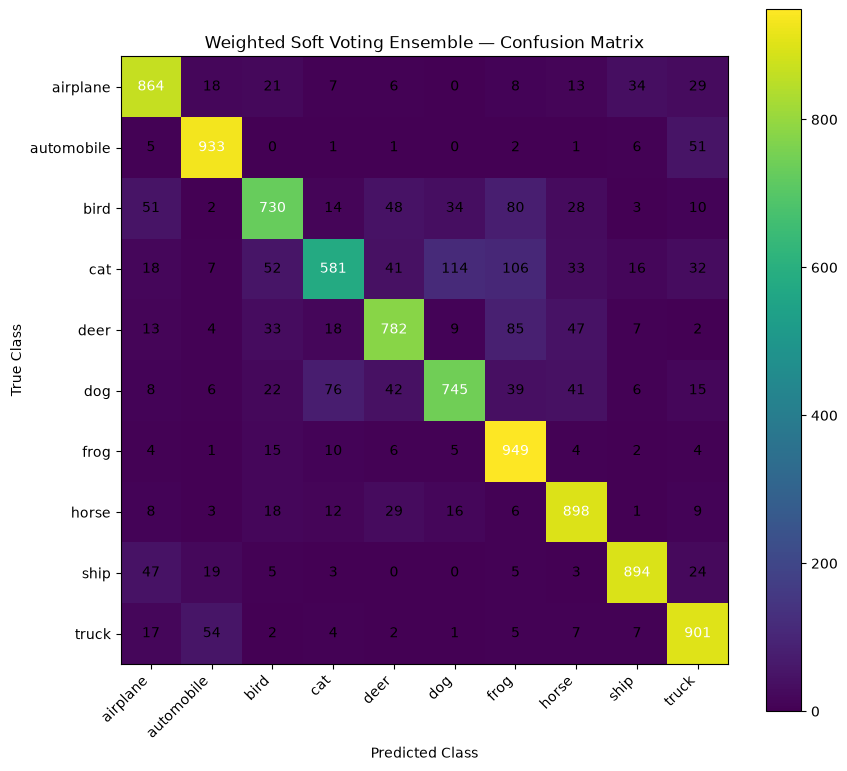

In [28]:
# Cell 28 — Save Ensemble Confusion Matrices

cm_majority = save_confusion_matrix(
    y_test,
    majority_preds,
    "Majority Voting Ensemble",
    "majority_voting_confusion_matrix.png"
)

cm_soft = save_confusion_matrix(
    y_test,
    soft_preds,
    "Soft Voting Ensemble",
    "ensemble_confusion_matrix.png"
)

cm_weighted = save_confusion_matrix(
    y_test,
    weighted_preds,
    "Weighted Soft Voting Ensemble",
    "weighted_voting_confusion_matrix.png"
)


## 12. Individual vs Ensemble Comparison


In [29]:
# Cell 29 — Final Classification Comparison

comparison_rows = [
    calculate_prediction_metrics(y_test, preds1, "CNN 1 - Baseline"),
    calculate_prediction_metrics(y_test, preds2, "CNN 2 - Regularized"),
    calculate_prediction_metrics(y_test, preds3, "CNN 3 - Deep"),
    majority_metrics,
    soft_metrics,
    weighted_metrics
]

model_comparison_df = pd.DataFrame(comparison_rows)

model_comparison_path = RESULTS_DIR / "model_comparison.csv"
model_comparison_df.to_csv(model_comparison_path, index=False)

display(model_comparison_df)

print("Saved:", model_comparison_path)


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,CNN 1 - Baseline,0.7349,0.733782,0.7349,0.729388
1,CNN 2 - Regularized,0.6924,0.704411,0.6924,0.683729
2,CNN 3 - Deep,0.8454,0.844552,0.8454,0.843532
3,Majority Voting,0.7977,0.798633,0.7977,0.794140
4,Soft Voting,0.8215,0.823389,0.8215,0.818211
5,Weighted Soft Voting,0.8277,0.828894,0.8277,0.824542


Saved: c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\results\model_comparison.csv


## 13. Robustness Testing

We create modified versions of test images:

- Original
- Rotated
- Blurred
- Noisy
- Darkened
- Brightened
- Cropped

The same modified images are evaluated by all models and the soft-voting ensemble.


In [30]:
# Cell 30 — Robustness Transformations

def make_robustness_variants(images):
    tensor = tf.convert_to_tensor(images, dtype=tf.float32)

    variants = {}

    variants["Original"] = tensor

    variants["Rotated"] = tf.image.rot90(tensor, k=1)

    variants["Blurred"] = tf.nn.avg_pool2d(
        tensor,
        ksize=3,
        strides=1,
        padding="SAME"
    )

    noise = tf.random.normal(
        shape=tf.shape(tensor),
        mean=0.0,
        stddev=0.08,
        seed=SEED
    )

    variants["Noisy"] = tf.clip_by_value(
        tensor + noise,
        0.0,
        1.0
    )

    variants["Darkened"] = tf.clip_by_value(
        tensor * 0.55,
        0.0,
        1.0
    )

    variants["Brightened"] = tf.clip_by_value(
        tensor * 1.35,
        0.0,
        1.0
    )

    cropped = tf.image.central_crop(tensor, central_fraction=0.80)
    variants["Cropped"] = tf.image.resize(
        cropped,
        [32, 32]
    )

    return {
        name: value.numpy()
        for name, value in variants.items()
    }


In [31]:
# Cell 31 — Create Robustness Dataset

# Use the full test set unless FAST_MODE is enabled.
robustness_images = X_test
robustness_labels = y_test

robustness_variants = make_robustness_variants(
    robustness_images
)

for name, images in robustness_variants.items():
    print(name, images.shape)


Original (10000, 32, 32, 3)
Rotated (10000, 32, 32, 3)
Blurred (10000, 32, 32, 3)
Noisy (10000, 32, 32, 3)
Darkened (10000, 32, 32, 3)
Brightened (10000, 32, 32, 3)
Cropped (10000, 32, 32, 3)


In [32]:
# Cell 32 — Evaluate Robustness

robustness_rows = []

for condition, images in robustness_variants.items():
    p1, p1_pred = get_predictions(cnn1, images)
    p2, p2_pred = get_predictions(cnn2, images)
    p3, p3_pred = get_predictions(cnn3, images)

    _, ensemble_pred = soft_voting([p1, p2, p3])

    robustness_rows.append({
        "condition": condition,
        "cnn1_accuracy": accuracy_score(robustness_labels, p1_pred),
        "cnn2_accuracy": accuracy_score(robustness_labels, p2_pred),
        "cnn3_accuracy": accuracy_score(robustness_labels, p3_pred),
        "ensemble_accuracy": accuracy_score(
            robustness_labels, ensemble_pred
        )
    })

robustness_df = pd.DataFrame(robustness_rows)

robustness_path = RESULTS_DIR / "robustness_results.csv"
robustness_df.to_csv(robustness_path, index=False)

display(robustness_df)

print("Saved:", robustness_path)


,condition,cnn1_accuracy,cnn2_accuracy,cnn3_accuracy,ensemble_accuracy
0,Original,0.7349,0.6924,0.8454,0.8215
1,Rotated,0.3151,0.2629,0.3292,0.3346
2,Blurred,0.6985,0.6466,0.7726,0.7736
3,Noisy,0.6262,0.2982,0.4633,0.4920
4,Darkened,0.6771,0.6034,0.8241,0.7947
5,Brightened,0.7046,0.6752,0.8180,0.8029
6,Cropped,0.6930,0.6882,0.8202,0.8079


Saved: c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\results\robustness_results.csv


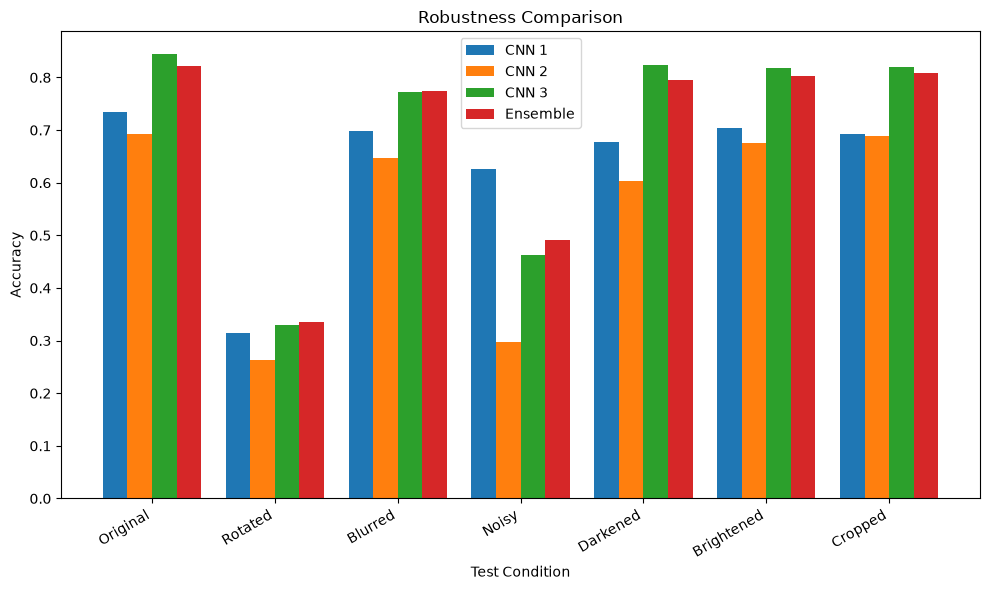

In [33]:
# Cell 33 — Robustness Accuracy Plot

fig = plt.figure(figsize=(10, 6))

x = np.arange(len(robustness_df))
width = 0.20

plt.bar(x - 1.5 * width, robustness_df["cnn1_accuracy"], width, label="CNN 1")
plt.bar(x - 0.5 * width, robustness_df["cnn2_accuracy"], width, label="CNN 2")
plt.bar(x + 0.5 * width, robustness_df["cnn3_accuracy"], width, label="CNN 3")
plt.bar(x + 1.5 * width, robustness_df["ensemble_accuracy"], width, label="Ensemble")

plt.xticks(x, robustness_df["condition"], rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.xlabel("Test Condition")
plt.title("Robustness Comparison")
plt.legend()
plt.tight_layout()

robustness_plot_path = RESULTS_DIR / "robustness_comparison.png"
plt.savefig(robustness_plot_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)


## 14. Model Disagreement Analysis

We measure:

- Percentage where all three CNNs agree
- Percentage where exactly two CNNs agree
- Percentage where all three predictions are different
- Disagreement rate


In [34]:
# Cell 34 — Model Disagreement Analysis

pred_matrix = np.column_stack([preds1, preds2, preds3])

all_agree_mask = (
    (pred_matrix[:, 0] == pred_matrix[:, 1]) &
    (pred_matrix[:, 1] == pred_matrix[:, 2])
)

all_different_mask = (
    (pred_matrix[:, 0] != pred_matrix[:, 1]) &
    (pred_matrix[:, 1] != pred_matrix[:, 2]) &
    (pred_matrix[:, 0] != pred_matrix[:, 2])
)

exactly_two_agree_mask = (
    (~all_agree_mask) &
    (~all_different_mask)
)

n = len(y_test)

disagreement_summary = pd.DataFrame([
    {
        "category": "All three agree",
        "count": int(all_agree_mask.sum()),
        "percentage": 100 * all_agree_mask.mean()
    },
    {
        "category": "Exactly two agree",
        "count": int(exactly_two_agree_mask.sum()),
        "percentage": 100 * exactly_two_agree_mask.mean()
    },
    {
        "category": "All three disagree",
        "count": int(all_different_mask.sum()),
        "percentage": 100 * all_different_mask.mean()
    },
    {
        "category": "Any disagreement",
        "count": int((~all_agree_mask).sum()),
        "percentage": 100 * (~all_agree_mask).mean()
    }
])

disagreement_path = RESULTS_DIR / "disagreement_results.csv"
disagreement_summary.to_csv(disagreement_path, index=False)

display(disagreement_summary)

print("Saved:", disagreement_path)


,category,count,percentage
0,All three agree,6310,63.1
1,Exactly two agree,3050,30.5
2,All three disagree,640,6.4
3,Any disagreement,3690,36.9


Saved: c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\results\disagreement_results.csv


Number of disagreement samples: 3690


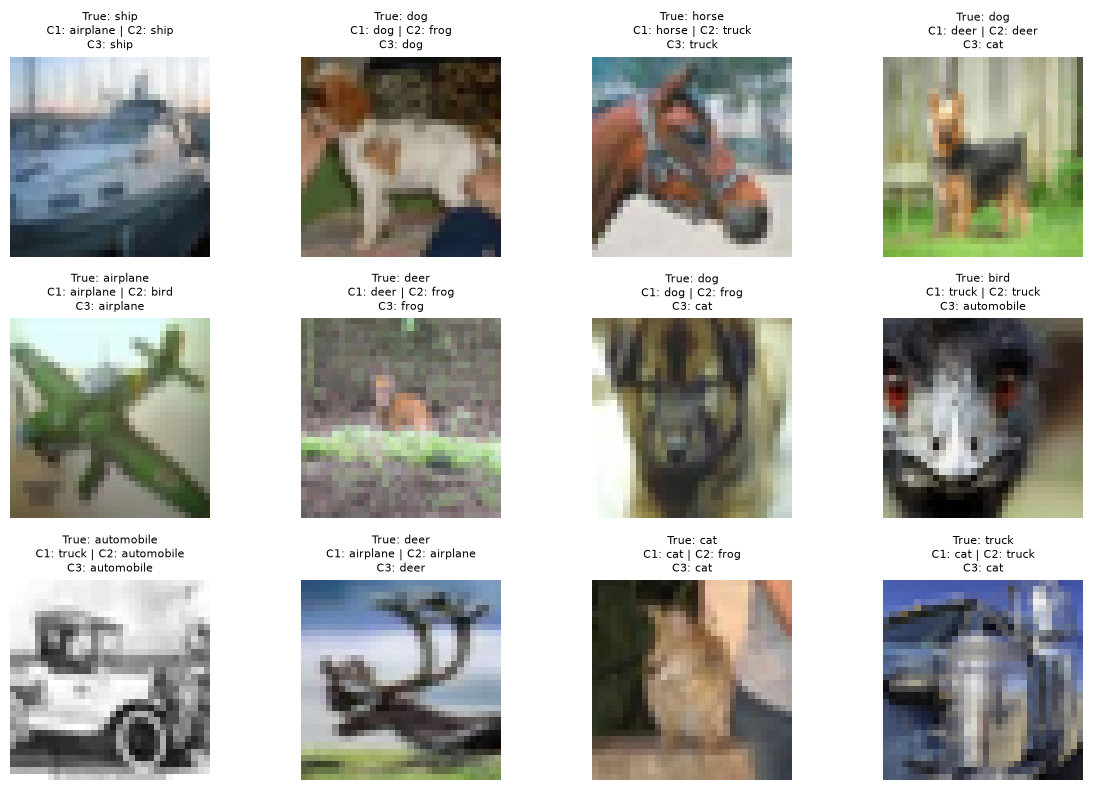

In [35]:
# Cell 35 — Example Disagreement Samples

disagreement_indices = np.where(~all_agree_mask)[0]

print("Number of disagreement samples:", len(disagreement_indices))

if len(disagreement_indices) > 0:
    sample_indices = disagreement_indices[:12]

    fig = plt.figure(figsize=(12, 8))

    for plot_i, idx in enumerate(sample_indices):
        plt.subplot(3, 4, plot_i + 1)
        plt.imshow(X_test[idx])

        title = (
            f"True: {CLASS_NAMES[y_test[idx]]}\n"
            f"C1: {CLASS_NAMES[preds1[idx]]} | "
            f"C2: {CLASS_NAMES[preds2[idx]]}\n"
            f"C3: {CLASS_NAMES[preds3[idx]]}"
        )

        plt.title(title, fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No disagreement samples found.")


## 15. Confidence Analysis

The final soft-voting prediction includes a confidence score equal to the highest averaged class probability.


In [36]:
# Cell 36 — Ensemble Confidence

ensemble_confidence = np.max(soft_probs, axis=1)

confidence_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": soft_preds,
    "true_class": [CLASS_NAMES[i] for i in y_test],
    "predicted_class": [CLASS_NAMES[i] for i in soft_preds],
    "confidence": ensemble_confidence
})

display(confidence_df.head(10))

print("Average ensemble confidence:", ensemble_confidence.mean())
print("Minimum ensemble confidence:", ensemble_confidence.min())
print("Maximum ensemble confidence:", ensemble_confidence.max())


,true_label,predicted_label,true_class,predicted_class,confidence
0,3,3,cat,cat,0.691498
1,8,8,ship,ship,0.968655
2,8,8,ship,ship,0.613985
3,0,0,airplane,airplane,0.832474
4,6,6,frog,frog,0.970166
5,6,6,frog,frog,0.979818
6,1,1,automobile,automobile,0.912403
7,6,6,frog,frog,0.709241
8,3,3,cat,cat,0.639059
9,1,1,automobile,automobile,0.899376


Average ensemble confidence: 0.7426919
Minimum ensemble confidence: 0.17230867
Maximum ensemble confidence: 0.9999878


In [37]:
# Cell 37 — Optional Confidence Threshold Analysis

CONFIDENCE_THRESHOLD = 0.80

accepted_mask = ensemble_confidence >= CONFIDENCE_THRESHOLD
manual_review_mask = ~accepted_mask

print(
    f"Accepted predictions: {accepted_mask.sum()} "
    f"({accepted_mask.mean() * 100:.2f}%)"
)

print(
    f"Manual review predictions: {manual_review_mask.sum()} "
    f"({manual_review_mask.mean() * 100:.2f}%)"
)

if accepted_mask.any():
    accepted_accuracy = accuracy_score(
        y_test[accepted_mask],
        soft_preds[accepted_mask]
    )
    print(
        f"Accuracy among accepted predictions: "
        f"{accepted_accuracy:.4f}"
    )


Accepted predictions: 4873 (48.73%)
Manual review predictions: 5127 (51.27%)
Accuracy among accepted predictions: 0.9746


## 16. Production Benchmarking

We measure:

- Parameter count
- Model file size
- Inference latency
- Throughput
- Process memory usage

Latency is measured over repeated prediction runs rather than a single prediction.


In [38]:
# Cell 38 — Model Size and Parameter Count

def get_model_size_mb(model_path):
    return model_path.stat().st_size / (1024 ** 2)


model_paths = {
    "CNN 1 - Baseline": MODELS_DIR / "cnn_baseline.keras",
    "CNN 2 - Regularized": MODELS_DIR / "cnn_regularized.keras",
    "CNN 3 - Deep": MODELS_DIR / "cnn_deep.keras"
}

model_objects = {
    "CNN 1 - Baseline": cnn1,
    "CNN 2 - Regularized": cnn2,
    "CNN 3 - Deep": cnn3
}

model_size_rows = []

for name, model in model_objects.items():
    path = model_paths[name]

    model_size_rows.append({
        "model": name,
        "parameters": model.count_params(),
        "model_size_mb": get_model_size_mb(path)
    })

model_size_df = pd.DataFrame(model_size_rows)

display(model_size_df)


,model,parameters,model_size_mb
0,CNN 1 - Baseline,545098,6.286071
1,CNN 2 - Regularized,357706,4.177107
2,CNN 3 - Deep,305706,3.584612


In [39]:
# Cell 39 — Memory Utility

try:
    import psutil
    PROCESS = psutil.Process(os.getpid())
    print("psutil available.")
except ImportError:
    PROCESS = None
    print("psutil is not installed. Memory measurement will be reported as unavailable.")


psutil available.


In [40]:
# Cell 40 — Latency and Throughput Benchmark

def benchmark_model(model, X, runs=5, batch_size=32):
    # Warm-up
    model.predict(X[:batch_size], batch_size=batch_size, verbose=0)

    latencies = []

    for _ in range(runs):
        start = time.perf_counter()

        model.predict(
            X,
            batch_size=batch_size,
            verbose=0
        )

        elapsed = time.perf_counter() - start

        latency_ms = (elapsed / len(X)) * 1000
        latencies.append(latency_ms)

    avg_latency_ms = float(np.mean(latencies))
    min_latency_ms = float(np.min(latencies))
    max_latency_ms = float(np.max(latencies))

    throughput = 1000.0 / avg_latency_ms

    return {
        "average_latency_ms_per_image": avg_latency_ms,
        "min_latency_ms_per_image": min_latency_ms,
        "max_latency_ms_per_image": max_latency_ms,
        "throughput_images_per_second": throughput
    }


benchmark_rows = []

for name, model in model_objects.items():
    result = benchmark_model(model, X_test, runs=5)

    memory_mb = np.nan

    if PROCESS is not None:
        before_mb = PROCESS.memory_info().rss / (1024 ** 2)

        model.predict(
            X_test[:BATCH_SIZE],
            batch_size=BATCH_SIZE,
            verbose=0
        )

        after_mb = PROCESS.memory_info().rss / (1024 ** 2)
        memory_mb = max(0.0, after_mb - before_mb)

    benchmark_rows.append({
        "model": name,
        **result,
        "memory_delta_mb": memory_mb
    })

benchmark_df = pd.DataFrame(benchmark_rows)

display(benchmark_df)


,model,average_latency_ms_per_image,min_latency_ms_per_image,max_latency_ms_per_image,throughput_images_per_second,memory_delta_mb
0,CNN 1 - Baseline,0.448446,0.349154,0.551099,2229.924262,0.007812
1,CNN 2 - Regularized,0.606221,0.535081,0.683439,1649.563127,0.007812
2,CNN 3 - Deep,1.821479,1.365846,2.357669,549.004483,0.359375


In [41]:
# Cell 41 — Benchmark the Ensemble

# Sequential ensemble benchmark: all three models are executed one after another.
def benchmark_ensemble(models, X, runs=5, batch_size=32):
    # Warm-up
    for model in models:
        model.predict(X[:batch_size], batch_size=batch_size, verbose=0)

    latencies = []

    for _ in range(runs):
        start = time.perf_counter()

        probabilities = []

        for model in models:
            probabilities.append(
                model.predict(
                    X,
                    batch_size=batch_size,
                    verbose=0
                )
            )

        _ = np.mean(np.stack(probabilities, axis=0), axis=0)

        elapsed = time.perf_counter() - start

        latency_ms = (elapsed / len(X)) * 1000
        latencies.append(latency_ms)

    avg_latency_ms = float(np.mean(latencies))
    min_latency_ms = float(np.min(latencies))
    max_latency_ms = float(np.max(latencies))

    throughput = 1000.0 / avg_latency_ms

    return {
        "average_latency_ms_per_image": avg_latency_ms,
        "min_latency_ms_per_image": min_latency_ms,
        "max_latency_ms_per_image": max_latency_ms,
        "throughput_images_per_second": throughput
    }


ensemble_benchmark = benchmark_ensemble(
    [cnn1, cnn2, cnn3],
    X_test,
    runs=5,
    batch_size=BATCH_SIZE
)

ensemble_memory_mb = np.nan

if PROCESS is not None:
    before_mb = PROCESS.memory_info().rss / (1024 ** 2)

    for model in [cnn1, cnn2, cnn3]:
        model.predict(
            X_test[:BATCH_SIZE],
            batch_size=BATCH_SIZE,
            verbose=0
        )

    after_mb = PROCESS.memory_info().rss / (1024 ** 2)
    ensemble_memory_mb = max(0.0, after_mb - before_mb)

ensemble_benchmark_row = {
    "model": "Soft Voting Ensemble",
    **ensemble_benchmark,
    "memory_delta_mb": ensemble_memory_mb
}

display(pd.DataFrame([ensemble_benchmark_row]))


,model,average_latency_ms_per_image,min_latency_ms_per_image,max_latency_ms_per_image,throughput_images_per_second,memory_delta_mb
0,Soft Voting Ensemble,4.106836,2.345828,6.394311,243.496455,0.0


In [42]:
# Cell 42 — Combine Full Benchmark Table

metric_lookup = {
    "CNN 1 - Baseline": metrics1,
    "CNN 2 - Regularized": metrics2,
    "CNN 3 - Deep": metrics3,
    "Soft Voting Ensemble": soft_metrics
}

benchmark_lookup = {
    row["model"]: row
    for row in benchmark_rows
}
benchmark_lookup["Soft Voting Ensemble"] = ensemble_benchmark_row

size_lookup = {
    row["model"]: row
    for row in model_size_rows
}

final_benchmark_rows = []

for name in [
    "CNN 1 - Baseline",
    "CNN 2 - Regularized",
    "CNN 3 - Deep",
    "Soft Voting Ensemble"
]:
    metric = metric_lookup[name]
    bench = benchmark_lookup[name]

    if name in size_lookup:
        parameters = size_lookup[name]["parameters"]
        model_size_mb = size_lookup[name]["model_size_mb"]
    else:
        parameters = (
            cnn1.count_params() +
            cnn2.count_params() +
            cnn3.count_params()
        )
        model_size_mb = sum(
            row["model_size_mb"] for row in model_size_rows
        )

    final_benchmark_rows.append({
        "model": name,
        "accuracy": metric["accuracy"],
        "precision_weighted": metric["precision_weighted"],
        "recall_weighted": metric["recall_weighted"],
        "f1_weighted": metric["f1_weighted"],
        "parameters": parameters,
        "model_size_mb": model_size_mb,
        "average_latency_ms_per_image": bench["average_latency_ms_per_image"],
        "min_latency_ms_per_image": bench["min_latency_ms_per_image"],
        "max_latency_ms_per_image": bench["max_latency_ms_per_image"],
        "throughput_images_per_second": bench["throughput_images_per_second"],
        "memory_delta_mb": bench["memory_delta_mb"]
    })

final_benchmark_df = pd.DataFrame(final_benchmark_rows)

benchmark_path = RESULTS_DIR / "benchmark_results.csv"
final_benchmark_df.to_csv(benchmark_path, index=False)

display(final_benchmark_df)

print("Saved:", benchmark_path)


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,parameters,model_size_mb,average_latency_ms_per_image,min_latency_ms_per_image,max_latency_ms_per_image,throughput_images_per_second,memory_delta_mb
0,CNN 1 - Baseline,0.7349,0.733782,0.7349,0.729388,545098,6.286071,0.448446,0.349154,0.551099,2229.924262,0.007812
1,CNN 2 - Regularized,0.6924,0.704411,0.6924,0.683729,357706,4.177107,0.606221,0.535081,0.683439,1649.563127,0.007812
2,CNN 3 - Deep,0.8454,0.844552,0.8454,0.843532,305706,3.584612,1.821479,1.365846,2.357669,549.004483,0.359375
3,Soft Voting Ensemble,0.8215,0.823389,0.8215,0.818211,1208510,14.047790,4.106836,2.345828,6.394311,243.496455,0.000000


Saved: c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\results\benchmark_results.csv


## 17. Production Trade-Off Analysis

The key question is not only "Which model has the highest accuracy?"

We compare accuracy improvement against latency, throughput, memory, model size and parameter count.


In [43]:
# Cell 43 — Production Trade-Off Calculations

best_individual_row = final_benchmark_df.iloc[
    final_benchmark_df["accuracy"].iloc[:3].idxmax()
]

ensemble_row = final_benchmark_df[
    final_benchmark_df["model"] == "Soft Voting Ensemble"
].iloc[0]

accuracy_gain = (
    ensemble_row["accuracy"] -
    best_individual_row["accuracy"]
) * 100

latency_increase = (
    ensemble_row["average_latency_ms_per_image"] -
    best_individual_row["average_latency_ms_per_image"]
)

throughput_change = (
    ensemble_row["throughput_images_per_second"] -
    best_individual_row["throughput_images_per_second"]
)

print("Best individual CNN:", best_individual_row["model"])
print(f"Best individual accuracy: {best_individual_row['accuracy']:.4f}")
print(f"Ensemble accuracy: {ensemble_row['accuracy']:.4f}")
print(f"Accuracy improvement: {accuracy_gain:.2f} percentage points")
print(f"Latency increase: {latency_increase:.4f} ms/image")
print(f"Throughput change: {throughput_change:.4f} images/sec")


Best individual CNN: CNN 3 - Deep
Best individual accuracy: 0.8454
Ensemble accuracy: 0.8215
Accuracy improvement: -2.39 percentage points
Latency increase: 2.2854 ms/image
Throughput change: -305.5080 images/sec


In [44]:
# Cell 44 — Final Comparison Table

final_comparison = final_benchmark_df[
    [
        "model",
        "accuracy",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
        "parameters",
        "model_size_mb",
        "average_latency_ms_per_image",
        "throughput_images_per_second",
        "memory_delta_mb"
    ]
].copy()

final_comparison = final_comparison.rename(columns={
    "model": "Model",
    "accuracy": "Accuracy",
    "precision_weighted": "Precision",
    "recall_weighted": "Recall",
    "f1_weighted": "F1-Score",
    "parameters": "Parameters",
    "model_size_mb": "Model Size (MB)",
    "average_latency_ms_per_image": "Avg Latency (ms/image)",
    "throughput_images_per_second": "Throughput (images/sec)",
    "memory_delta_mb": "Memory Delta (MB)"
})

final_table_path = RESULTS_DIR / "final_benchmark_table.csv"
final_comparison.to_csv(final_table_path, index=False)

display(final_comparison)

print("Saved:", final_table_path)


,Model,Accuracy,Precision,Recall,F1-Score,Parameters,Model Size (MB),Avg Latency (ms/image),Throughput (images/sec),Memory Delta (MB)
0,CNN 1 - Baseline,0.7349,0.733782,0.7349,0.729388,545098,6.286071,0.448446,2229.924262,0.007812
1,CNN 2 - Regularized,0.6924,0.704411,0.6924,0.683729,357706,4.177107,0.606221,1649.563127,0.007812
2,CNN 3 - Deep,0.8454,0.844552,0.8454,0.843532,305706,3.584612,1.821479,549.004483,0.359375
3,Soft Voting Ensemble,0.8215,0.823389,0.8215,0.818211,1208510,14.047790,4.106836,243.496455,0.000000


Saved: c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\results\final_benchmark_table.csv


## 18. Production Recommendation

Use evidence from the benchmark results.

A useful rule:

- If the ensemble gives a meaningful accuracy/robustness improvement and latency is acceptable, choose the ensemble.
- If the accuracy gain is small but latency and resource costs are much higher, choose the best individual CNN.
- For real-time systems, latency and throughput can be more important.
- For offline/batch processing, higher accuracy and robustness may justify extra computation.


In [45]:
# Cell 45 — Generate Production Recommendation

best_individual_name = best_individual_row["model"]

if accuracy_gain >= 1.0 and latency_increase <= 50:
    recommendation = (
        f"Recommended deployment: Soft Voting Ensemble. "
        f"It improves accuracy by {accuracy_gain:.2f} percentage points "
        f"over {best_individual_name}, while the measured latency increase "
        f"is {latency_increase:.2f} ms/image. This is a reasonable trade-off "
        f"when accuracy and robustness are important."
    )
else:
    recommendation = (
        f"Recommended deployment: {best_individual_name}. "
        f"The ensemble's measured accuracy improvement is "
        f"{accuracy_gain:.2f} percentage points, while its latency increases "
        f"by {latency_increase:.2f} ms/image. A single strong CNN may provide "
        f"a better production cost/performance balance."
    )

print(recommendation)


Recommended deployment: CNN 3 - Deep. The ensemble's measured accuracy improvement is -2.39 percentage points, while its latency increases by 2.29 ms/image. A single strong CNN may provide a better production cost/performance balance.


In [46]:
# Cell 46 — Save Production Recommendation

recommendation_path = RESULTS_DIR / "production_recommendation.txt"

with open(recommendation_path, "w", encoding="utf-8") as f:
    f.write(recommendation + "\n")

print("Saved:", recommendation_path)


Saved: c:\Users\S_Gayathri\open-data-intelligence-hub\Mentee Contribution\Task 15 - Production-Grade Ensemble CNN Classifier with Performance Benchmarks\S.GayathriG40-AIML\notebook\results\production_recommendation.txt


In [47]:
# Cell 47 — Final Output Inventory

print("\nMODELS:")
for path in sorted(MODELS_DIR.glob("*.keras")):
    print(" -", path.name)

print("\nRESULTS:")
for path in sorted(RESULTS_DIR.iterdir()):
    if path.is_file():
        print(" -", path.name)

print("\nTask 15 notebook execution pipeline completed.")



MODELS:
 - cnn_baseline.keras
 - cnn_deep.keras
 - cnn_regularized.keras

RESULTS:
 - benchmark_results.csv
 - cnn1_confusion_matrix.png
 - cnn2_confusion_matrix.png
 - cnn3_confusion_matrix.png
 - disagreement_results.csv
 - ensemble_confusion_matrix.png
 - final_benchmark_table.csv
 - majority_voting_confusion_matrix.png
 - model_comparison.csv
 - production_recommendation.txt
 - robustness_comparison.png
 - robustness_results.csv
 - training_accuracy_cnn1.png
 - training_accuracy_cnn2.png
 - training_accuracy_cnn3.png
 - training_history_cnn1.csv
 - training_history_cnn2.csv
 - training_history_cnn3.csv
 - training_loss_cnn1.png
 - training_loss_cnn2.png
 - training_loss_cnn3.png
 - weighted_voting_confusion_matrix.png

Task 15 notebook execution pipeline completed.


## 20. Notes for Submission

The numerical benchmark values in this notebook are generated from the actual run. Do not replace them with example values from the task description.

Commit the generated CSV results and required visual outputs to the `results/` folder. Do not commit the CIFAR-10 dataset itself.

The three trained `.keras` models are generated under `models/`.

For a clean Git submission, also ensure that temporary files such as Python cache folders and Jupyter checkpoint folders are ignored.
